In [43]:
from scipy.signal import welch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [34]:
data1 = pd.read_csv('D:/UHF Pollution Flashover/1.csv', header=None)
data2 = pd.read_csv('D:/UHF Pollution Flashover/2.csv', header=None)

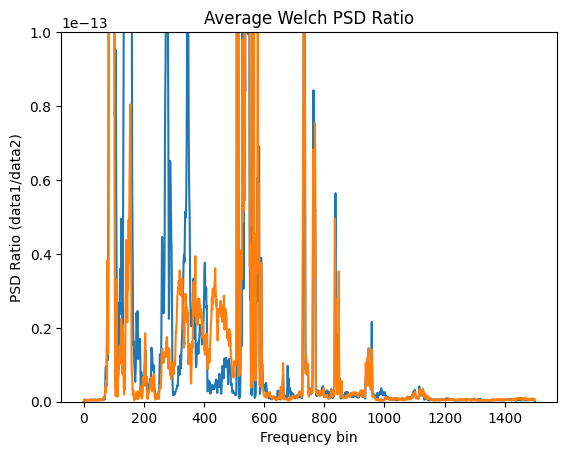

1501

In [ ]:
# Compute Welch PSD for all columns in data1 and data2
pxx1_all = []
pxx2_all = []

for col in data1.columns:
    _, pxx = welch(data1[col], fs=3e9, nperseg=3000, scaling='density')
    pxx1_all.append(pxx)
    
for col in data2.columns:
    _, pxx = welch(data2[col], fs=3e9, nperseg=3000, scaling='density')
    pxx2_all.append(pxx)

# Average PSD across all columns
pxx1_mean = np.mean(pxx1_all, axis=0)
pxx2_mean = np.mean(pxx2_all, axis=0)

# Plot the ratio
plt.figure()
plt.plot(pxx1_mean)
plt.plot(pxx2_mean)
plt.xlabel('Frequency bin')
plt.ylabel('PSD Ratio (data1/data2)')
plt.title('Average Welch PSD Ratio')

plt.ylim(0, 0.1e-12)
plt.show()

plt.figure()
plt.plot(pxx1_mean)
plt.plot(pxx2_mean)
plt.xlabel('Frequency bin')
plt.ylabel('PSD Ratio (data1/data2)')
plt.title('Average Welch PSD Ratio')

plt.ylim(0, 0.1e-12)
plt.show()


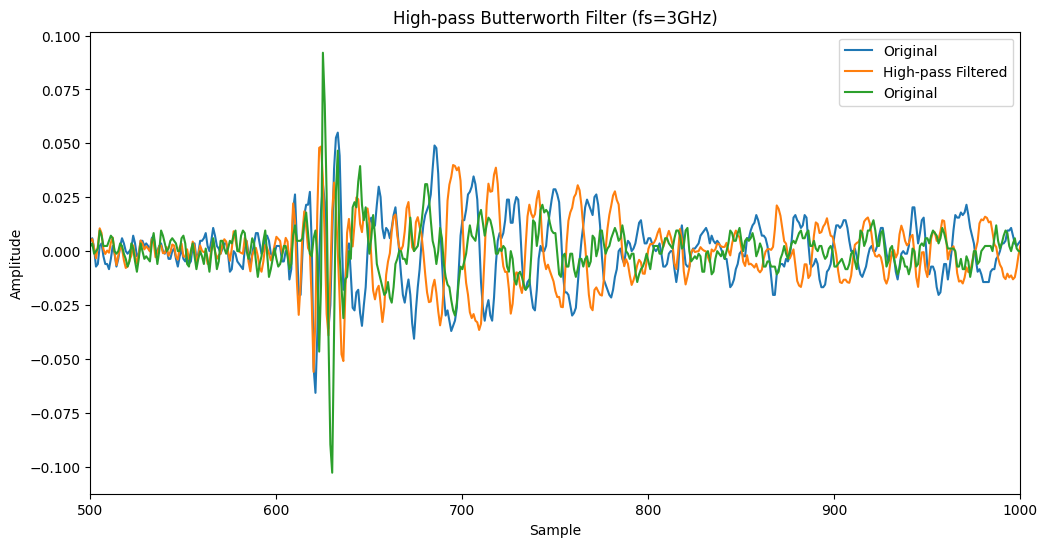

In [33]:
from scipy.signal import butter, sosfilt

# Design high-pass Butterworth filter
# fs = 3e9 Hz (sampling frequency)
# Choose cutoff frequency and order (e.g., 1 GHz cutoff, order 5)
fs = 3e9
cutoff = 0.1e9  # 1 GHz cutoff frequency
order = 5

# Create high-pass filter
sos = butter(order, cutoff, btype='high', fs=fs, output='sos')

# Apply filter to first signal (column 1 of data1)
filtered_signal = sosfilt(sos, data1[1])

# Plot original and filtered signals
plt.figure(figsize=(12, 6))
plt.plot(data1[1], label='Original')
plt.plot(filtered_signal, label='High-pass Filtered')
plt.plot(data2[1], label='Original')
plt.legend()
plt.xlim(300,1000)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('High-pass Butterworth Filter (fs=3GHz)')
plt.show()